<a href="https://colab.research.google.com/github/reyhan1997/museum_zoo_aqua/blob/main/museum_zoo_aqua_graph_map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [64]:
url = 'https://raw.githubusercontent.com/reyhan1997/museum_zoo_aqua/refs/heads/main/museums.csv'

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
df = pd.read_csv(url)
df.head()

/tmp/ipykernel_677/3173042584.py:1: DtypeWarning: Columns (9,14,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


,Museum ID,Museum Name,Legal Name,Alternate Name,Museum Type,Institution Name,Street Address (Administrative Location),City (Administrative Location),State (Administrative Location),Zip Code (Administrative Location),...,Latitude,Longitude,Locale Code (NCES),County Code (FIPS),State Code (FIPS),Region Code (AAM),Employer ID Number,Tax Period,Income,Revenue
0,8400200098,ALASKA AVIATION HERITAGE MUSEUM,ALASKA AVIATION HERITAGE MUSEUM,NaN,HISTORY MUSEUM,NaN,4721 AIRCRAFT DR,ANCHORAGE,AK,99502,...,61.17925,-149.97254,1.0,20.0,2.0,6,920071852,201312.0,602912.0,550236.0
1,8400200117,ALASKA BOTANICAL GARDEN,ALASKA BOTANICAL GARDEN INC,NaN,"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER",NaN,4601 CAMPBELL AIRSTRIP RD,ANCHORAGE,AK,99507,...,61.16890,-149.76708,4.0,20.0,2.0,6,920115504,201312.0,1379576.0,1323742.0
2,8400200153,ALASKA CHALLENGER CENTER FOR SPACE SCIENCE TEC...,ALASKA CHALLENGER CENTER FOR SPACE SCIENCE TEC...,NaN,SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,NaN,9711 KENAI SPUR HWY,KENAI,AK,99611,...,60.56149,-151.21598,3.0,122.0,2.0,6,921761906,201312.0,740030.0,729080.0
3,8400200143,ALASKA EDUCATORS HISTORICAL SOCIETY,ALASKA EDUCATORS HISTORICAL SOCIETY,NaN,HISTORIC PRESERVATION,NaN,214 BIRCH STREET,KENAI,AK,99611,...,60.56280,-151.26597,3.0,122.0,2.0,6,920165178,201412.0,0.0,0.0
4,8400200027,ALASKA HERITAGE MUSEUM,ALASKA AVIATION HERITAGE MUSEUM,NaN,HISTORY MUSEUM,NaN,301 W NORTHERN LIGHTS BLVD,ANCHORAGE,AK,99503,...,61.17925,-149.97254,1.0,20.0,2.0,6,920071852,201312.0,602912.0,550236.0


In [67]:
df.tail()

,Museum ID,Museum Name,Legal Name,Alternate Name,Museum Type,Institution Name,Street Address (Administrative Location),City (Administrative Location),State (Administrative Location),Zip Code (Administrative Location),...,Latitude,Longitude,Locale Code (NCES),County Code (FIPS),State Code (FIPS),Region Code (AAM),Employer ID Number,Tax Period,Income,Revenue
33067,8405600184,WYOMING STATE HISTORICAL SOCIETY,WYOMING STATE HISTORICAL SOCIETY,NaN,HISTORIC PRESERVATION,NaN,PO BOX 73,SHERIDAN,WY,82801,...,44.82345,-106.87592,4.0,33.0,56.0,5,836007540.0,NaN,NaN,NaN
33068,8405600061,WYOMING STATE MUSEUM,WYOMING STATE MUSEUM VOLUNTEERS INC,NaN,GENERAL MUSEUM,NaN,2301 CENTRAL AVENUE,CHEYENNE,WY,82001,...,41.13941,-104.81813,1.0,21.0,56.0,5,237368629.0,201404.0,0.0,0.0
33069,8405600158,WYOMING TERRITORIAL PARK HISTORIC ASSOCIATION,WYOMING TERRITORIAL PARK HISTORIC ASSOCIATION INC,NaN,HISTORIC PRESERVATION,NaN,1273 N 15TH ST STE 121,LARAMIE,WY,82072,...,41.32276,-105.57686,3.0,1.0,56.0,5,830318392.0,201312.0,208508.0,83981.0
33070,8405600137,WYOMING TRANSPORTATION MUSEUM,WYOMING TRANSPORTATION MUSEUM CORP,NaN,HISTORY MUSEUM,NaN,PO BOX 704,CHEYENNE,WY,82003,...,41.13010,-104.81916,1.0,21.0,56.0,5,830295570.0,201309.0,0.0,0.0
33071,8405600199,YELLOWSTONE NATIONAL PARK,LITTLE PEOPLE LEARNING CENTER INC,NaN,HISTORIC PRESERVATION,NaN,NATIONAL PARK SERVICE,YELLOWSTONE NATIONAL PARK,WY,82190,...,44.91303,-110.41584,4.0,29.0,56.0,5,830249072.0,201312.0,127496.0,126762.0


In [68]:
df.shape

(33072, 25)

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33072 entries, 0 to 33071
Data columns (total 25 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Museum ID                                 33072 non-null  int64  
 1   Museum Name                               33072 non-null  object 
 2   Legal Name                                33072 non-null  object 
 3   Alternate Name                            1927 non-null   object 
 4   Museum Type                               33072 non-null  object 
 5   Institution Name                          2749 non-null   object 
 6   Street Address (Administrative Location)  33062 non-null  object 
 7   City (Administrative Location)            33072 non-null  object 
 8   State (Administrative Location)           33072 non-null  object 
 9   Zip Code (Administrative Location)        33072 non-null  object 
 10  Street Address (Physical Location)

In [70]:
df.isnull().sum()

,0
Museum ID,0
Museum Name,0
Legal Name,0
Alternate Name,31145
Museum Type,0
Institution Name,30323
Street Address (Administrative Location),10
City (Administrative Location),0
State (Administrative Location),0
Zip Code (Administrative Location),0


In [71]:
df.fillna({'Locale Code (NCES)':0},inplace=True)
df_NCES = df['Locale Code (NCES)'].astype(np.int64)
df_NCES

,Locale Code (NCES)
0,1
1,4
2,3
3,3
4,1
...,...
33067,4
33068,1
33069,3
33070,1


In [72]:
df['Locale Code (NCES)'].value_counts(int)*100

,proportion
Locale Code (NCES),
4.0,31.779149
1.0,29.006410
2.0,23.067852
3.0,15.913764
0.0,0.232825


In [73]:
#Example df.fillna({'Locale Code (NCES)':0},inplace=True)
df.fillna({'County Code (FIPS)':0},inplace=True)
df['County Code (FIPS)'].astype(np.int64)
df['County Code (FIPS)'].value_counts().head(20)

,count
County Code (FIPS),
0.0,2536
1.0,1020
3.0,913
37.0,797
31.0,797
13.0,732
5.0,667
61.0,631
17.0,610


In [74]:
df['Alternate Name'].value_counts()

,count
Alternate Name,
REGENTS OF THE UNIVERSITY OF CALIFORNIA LOS ANGELES,7
SMITHSONIAN INSTITUTION,5
GALLERY OF CONTEMPORARY ART,5
UNIVERSITY OF CALIFORNIA DAVIS,4
UNIVERSITY OF ILLINOIS,3
...,...
PIANKESHAW TRAILS EDUCTL PK,1
NORTHERN INDIANA HISTORICAL SOCIETY,1
MUNCIE CHILDREN'S MUSEUM,1


In [75]:
df_IN_count = df['Institution Name'].value_counts()
display(df_IN_count)

,count
Institution Name,
PENNSYLVANIA STATE UNIVERSITY,22
HARVARD UNIVERSITY,20
ARIZONA STATE UNIVERSITY,19
UNIVERSITY OF MICHIGAN,16
UNIVERSITY OF WISCONSIN-MADISON,13
...,...
OAKLAND UNIVERSITY,1
UNIVERSITY OF DETROIT MERCY,1
JACKSON COLLEGE,1


In [76]:
df[['Income', 'Revenue']].describe()

,Income,Revenue
count,2.296100e+04,2.229000e+04
mean,1.069682e+08,2.097605e+07
std,2.509287e+09,2.485197e+08
min,-9.230000e+02,-2.127393e+06
25%,0.000000e+00,0.000000e+00
50%,8.781000e+03,3.307000e+03
75%,2.163770e+05,1.676960e+05
max,8.318144e+10,5.840349e+09


In [77]:
#Convert tax date from float64 into datetime data types
tax_date = pd.to_datetime(df['Tax Period'], format='%Y%m', errors = 'coerce')
tax_date

,Tax Period
0,2013-12-01
1,2013-12-01
2,2013-12-01
3,2014-12-01
4,2013-12-01
...,...
33067,NaT
33068,2014-04-01
33069,2013-12-01
33070,2013-09-01


In [78]:
tax_date.value_counts()

,count
Tax Period,
2013-12-01,10157
2014-12-01,4683
2014-06-01,2577
2013-06-01,1343
2014-09-01,616
...,...
2002-12-01,1
2007-12-01,1
2011-08-01,1


In [79]:
number_of_museum_type = df['Museum Type'].value_counts()
number_of_museum_type

,count
Museum Type,
HISTORIC PRESERVATION,14861
GENERAL MUSEUM,8699
ART MUSEUM,3241
HISTORY MUSEUM,2284
"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER",1484
SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,1081
"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",564
CHILDREN'S MUSEUM,512
NATURAL HISTORY MUSEUM,346


In [80]:
revenue_museum = df.groupby('Museum Type')['Income'].sum()
revenue_museum

,Income
Museum Type,
"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER",3.730393e+11
ART MUSEUM,6.143317e+11
CHILDREN'S MUSEUM,6.480484e+08
GENERAL MUSEUM,7.668677e+11
HISTORIC PRESERVATION,1.188386e+11
HISTORY MUSEUM,3.586002e+10
NATURAL HISTORY MUSEUM,1.439225e+11
SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,4.006399e+11
"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",1.948786e+09


In [81]:
df.groupby('Museum Type')[['Income', 'Revenue']].sum()

,Income,Revenue
Museum Type,,
"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER",3.730393e+11,5.778638e+10
ART MUSEUM,6.143317e+11,1.858520e+11
CHILDREN'S MUSEUM,6.480484e+08,4.404932e+08
GENERAL MUSEUM,7.668677e+11,1.104060e+11
HISTORIC PRESERVATION,1.188386e+11,2.520482e+10
HISTORY MUSEUM,3.586002e+10,1.907755e+10
NATURAL HISTORY MUSEUM,1.439225e+11,2.009211e+10
SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,4.006399e+11,4.709544e+10
"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",1.948786e+09,1.601212e+09


In [82]:
income_museum = df.groupby('Museum Type')['Revenue'].sum()
income_museum

,Revenue
Museum Type,
"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER",5.778638e+10
ART MUSEUM,1.858520e+11
CHILDREN'S MUSEUM,4.404932e+08
GENERAL MUSEUM,1.104060e+11
HISTORIC PRESERVATION,2.520482e+10
HISTORY MUSEUM,1.907755e+10
NATURAL HISTORY MUSEUM,2.009211e+10
SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,4.709544e+10
"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",1.601212e+09


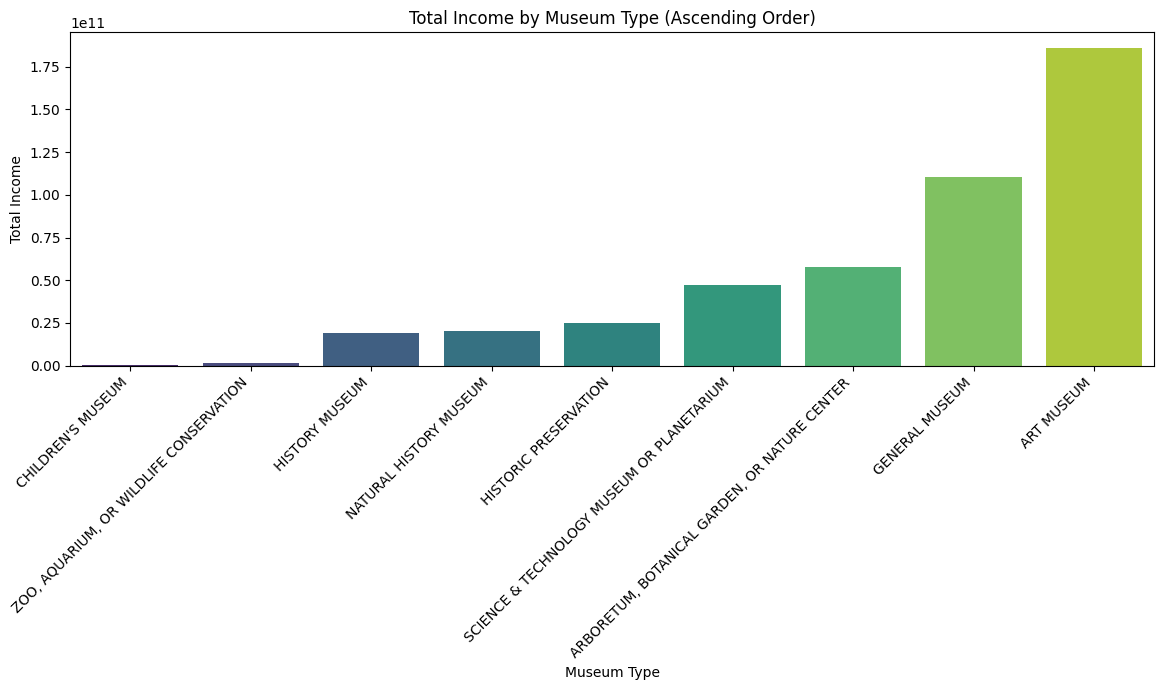

In [83]:
plt.figure(figsize=(12, 7))
# Sort the income_museum series in ascending order before plotting
sorted_income_museum = income_museum.sort_values(ascending=True)
sns.barplot(x=sorted_income_museum.index, y=sorted_income_museum.values, hue=sorted_income_museum.index, palette='viridis', legend=False)
plt.title('Total Income by Museum Type (Ascending Order)')
plt.xlabel('Museum Type')
plt.ylabel('Total Income')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [85]:
#Confirm which museum type with null input in income and revenue
null_counts_by_museum_type = df.groupby('Museum Type')[['Income', 'Revenue']].apply(lambda x: x.isnull().sum())
display(null_counts_by_museum_type)

,Income,Revenue
Museum Type,,
"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER",708,742
ART MUSEUM,1335,1397
CHILDREN'S MUSEUM,182,187
GENERAL MUSEUM,4373,4670
HISTORIC PRESERVATION,2317,2479
HISTORY MUSEUM,170,255
NATURAL HISTORY MUSEUM,102,111
SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,662,669
"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",262,272


In [86]:
#Confirm the cell with null input value
df_clean = df.isnull().dropna()
df_clean

,Museum ID,Museum Name,Legal Name,Alternate Name,Museum Type,Institution Name,Street Address (Administrative Location),City (Administrative Location),State (Administrative Location),Zip Code (Administrative Location),...,Latitude,Longitude,Locale Code (NCES),County Code (FIPS),State Code (FIPS),Region Code (AAM),Employer ID Number,Tax Period,Income,Revenue
0,False,False,False,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33067,False,False,False,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,True,True
33068,False,False,False,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
33069,False,False,False,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
33070,False,False,False,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [87]:
#Clear the null value

In [88]:
print(f"Original DataFrame shape: {df.shape}")

# Drop rows where 'Income' or 'Revenue' are null
df_cleaned = df.dropna(subset=['Income', 'Revenue'])

print(f"DataFrame shape after dropping nulls in 'Income' or 'Revenue': {df_cleaned.shape}")

# Update the main dataframe 'df' with the cleaned data
display(df_cleaned)

Original DataFrame shape: (33072, 25)
DataFrame shape after dropping nulls in 'Income' or 'Revenue': (22290, 25)


,Museum ID,Museum Name,Legal Name,Alternate Name,Museum Type,Institution Name,Street Address (Administrative Location),City (Administrative Location),State (Administrative Location),Zip Code (Administrative Location),...,Latitude,Longitude,Locale Code (NCES),County Code (FIPS),State Code (FIPS),Region Code (AAM),Employer ID Number,Tax Period,Income,Revenue
0,8400200098,ALASKA AVIATION HERITAGE MUSEUM,ALASKA AVIATION HERITAGE MUSEUM,NaN,HISTORY MUSEUM,NaN,4721 AIRCRAFT DR,ANCHORAGE,AK,99502,...,61.17925,-149.97254,1.0,20.0,2.0,6,920071852,201312.0,602912.0,550236.0
1,8400200117,ALASKA BOTANICAL GARDEN,ALASKA BOTANICAL GARDEN INC,NaN,"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER",NaN,4601 CAMPBELL AIRSTRIP RD,ANCHORAGE,AK,99507,...,61.16890,-149.76708,4.0,20.0,2.0,6,920115504,201312.0,1379576.0,1323742.0
2,8400200153,ALASKA CHALLENGER CENTER FOR SPACE SCIENCE TEC...,ALASKA CHALLENGER CENTER FOR SPACE SCIENCE TEC...,NaN,SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,NaN,9711 KENAI SPUR HWY,KENAI,AK,99611,...,60.56149,-151.21598,3.0,122.0,2.0,6,921761906,201312.0,740030.0,729080.0
3,8400200143,ALASKA EDUCATORS HISTORICAL SOCIETY,ALASKA EDUCATORS HISTORICAL SOCIETY,NaN,HISTORIC PRESERVATION,NaN,214 BIRCH STREET,KENAI,AK,99611,...,60.56280,-151.26597,3.0,122.0,2.0,6,920165178,201412.0,0.0,0.0
4,8400200027,ALASKA HERITAGE MUSEUM,ALASKA AVIATION HERITAGE MUSEUM,NaN,HISTORY MUSEUM,NaN,301 W NORTHERN LIGHTS BLVD,ANCHORAGE,AK,99503,...,61.17925,-149.97254,1.0,20.0,2.0,6,920071852,201312.0,602912.0,550236.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33063,8405600122,WYOMING SECONDARY ART EDUCATORS ASSOCIATION,WYOMING SECONDARY ART EDUCATORS ASSOCIATION INC,NaN,ART MUSEUM,NaN,601 GRACE AVE,WORLAND,WY,82401,...,44.01382,-107.96000,3.0,43.0,56.0,5,830265250.0,201312.0,43695.0,43695.0
33068,8405600061,WYOMING STATE MUSEUM,WYOMING STATE MUSEUM VOLUNTEERS INC,NaN,GENERAL MUSEUM,NaN,2301 CENTRAL AVENUE,CHEYENNE,WY,82001,...,41.13941,-104.81813,1.0,21.0,56.0,5,237368629.0,201404.0,0.0,0.0
33069,8405600158,WYOMING TERRITORIAL PARK HISTORIC ASSOCIATION,WYOMING TERRITORIAL PARK HISTORIC ASSOCIATION INC,NaN,HISTORIC PRESERVATION,NaN,1273 N 15TH ST STE 121,LARAMIE,WY,82072,...,41.32276,-105.57686,3.0,1.0,56.0,5,830318392.0,201312.0,208508.0,83981.0
33070,8405600137,WYOMING TRANSPORTATION MUSEUM,WYOMING TRANSPORTATION MUSEUM CORP,NaN,HISTORY MUSEUM,NaN,PO BOX 704,CHEYENNE,WY,82003,...,41.13010,-104.81916,1.0,21.0,56.0,5,830295570.0,201309.0,0.0,0.0


In [89]:
df['Region Code (AAM)'].value_counts()

,count
Region Code (AAM),
4,7353
3,6670
2,5624
6,5306
5,5188
1,2931


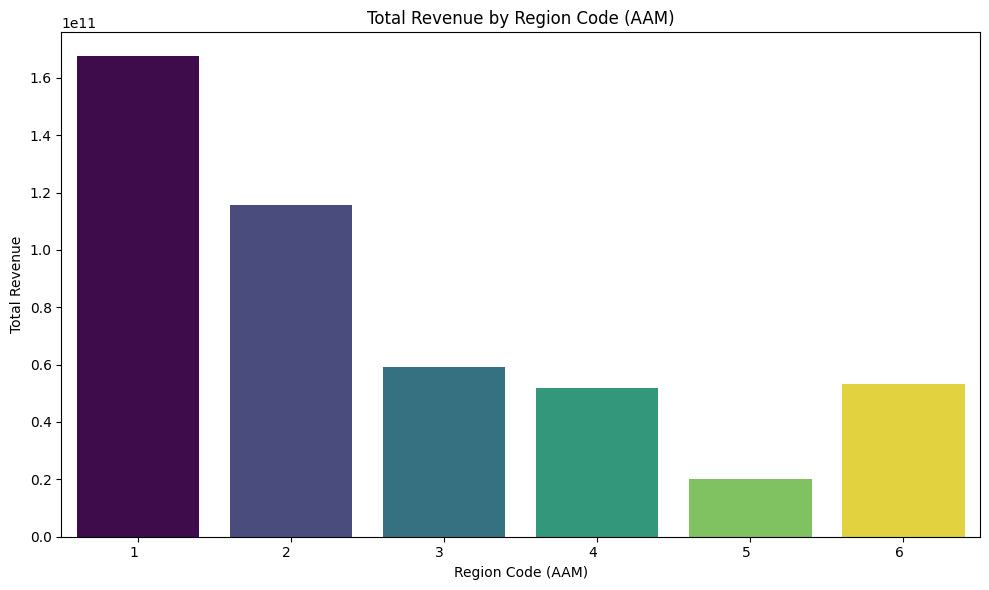

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

revenue_by_region = df_cleaned.groupby('Region Code (AAM)')['Revenue'].sum()

plt.figure(figsize=(10, 6))
sns.barplot(x=revenue_by_region.index, y=revenue_by_region.values, hue=revenue_by_region.index, palette='viridis', legend=False)
plt.title('Total Revenue by Region Code (AAM)')
plt.xlabel('Region Code (AAM)')
plt.ylabel('Total Revenue')
plt.xticks(ha='right')
plt.tight_layout()
plt.show()

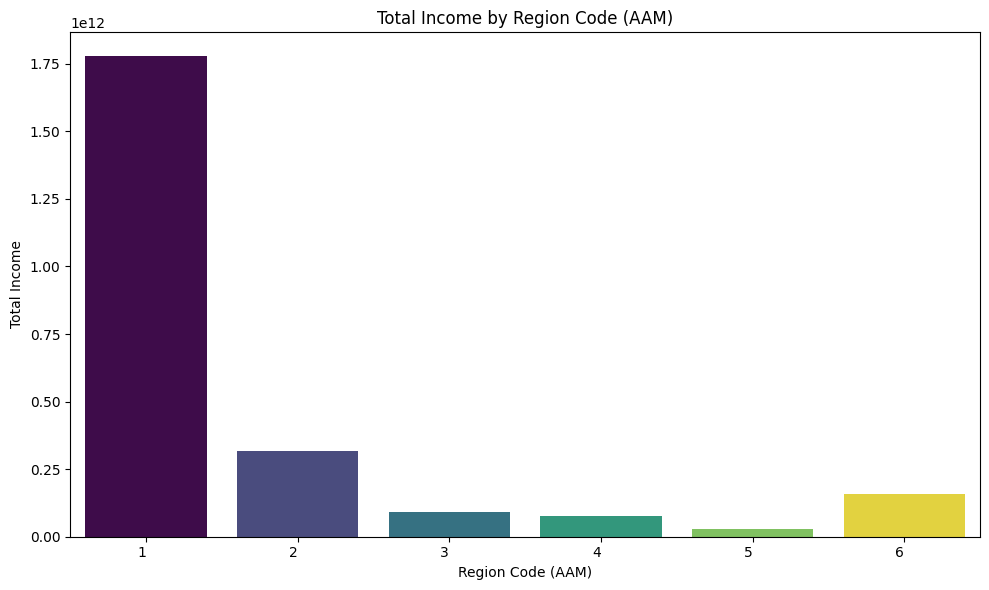

In [91]:
income_by_region = df_cleaned.groupby('Region Code (AAM)')['Income'].sum()

plt.figure(figsize=(10, 6))
sns.barplot(x=income_by_region.index, y=income_by_region.values, hue=income_by_region.index, palette='viridis', legend=False)
plt.title('Total Income by Region Code (AAM)')
plt.xlabel('Region Code (AAM)')
plt.ylabel('Total Income')
plt.xticks(ha='right')
plt.tight_layout()
plt.show()

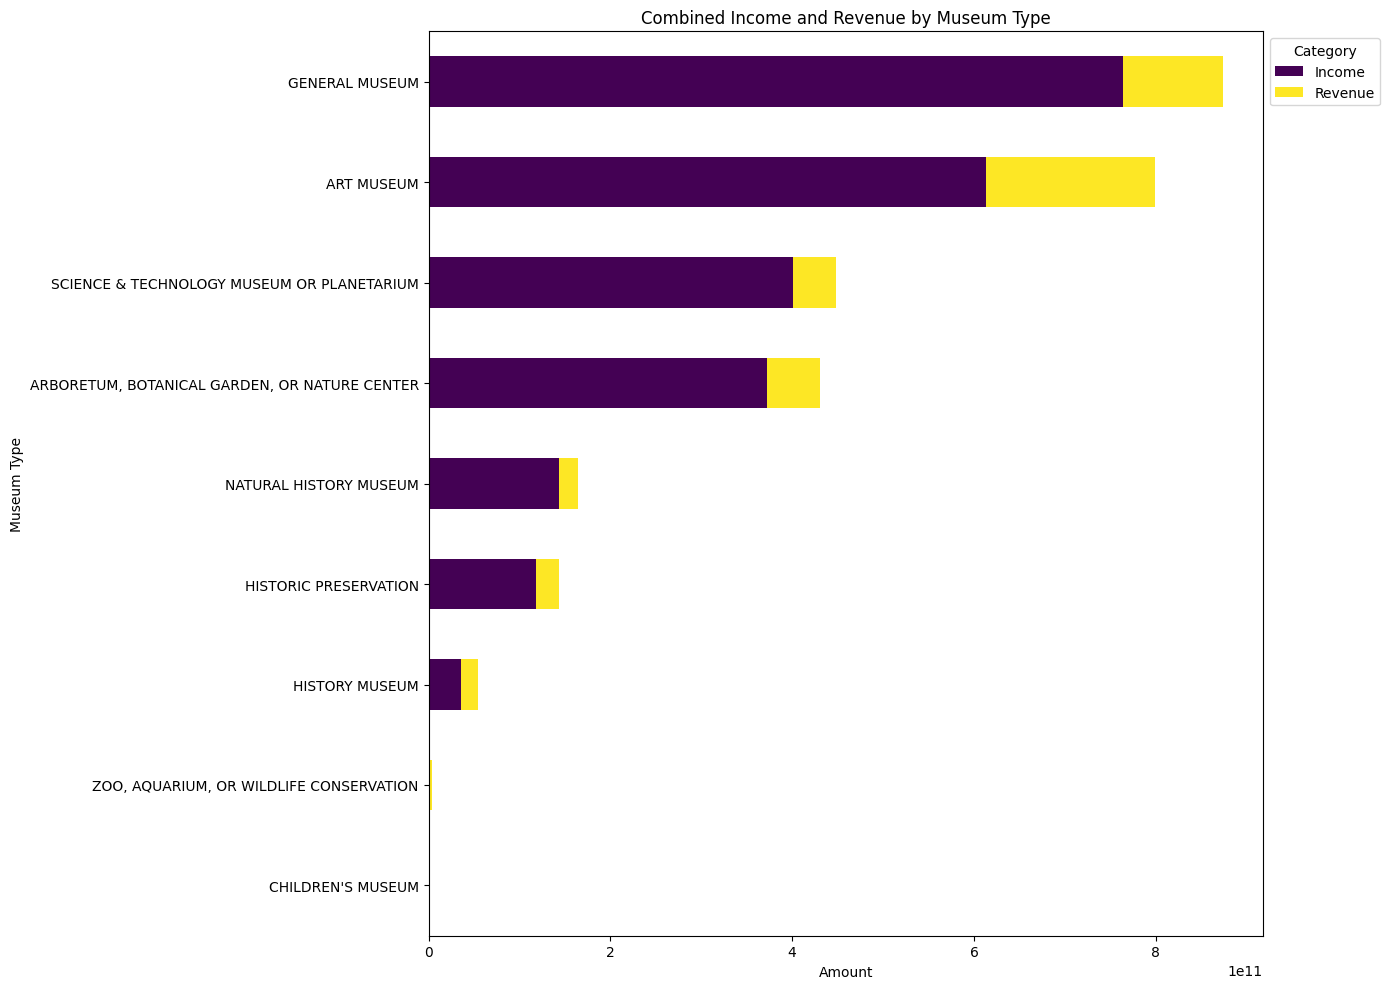

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Group by 'Museum Type' and sum 'Income' and 'Revenue'
combined_data = df_cleaned.groupby('Museum Type')[['Income', 'Revenue']].sum()

# Sort the data by total of Income + Revenue for better visualization (descending order)
combined_data['Total'] = combined_data['Income'] + combined_data['Revenue']
combined_data = combined_data.sort_values(by='Total', ascending=True).drop('Total', axis=1)

# Plotting the stacked horizontal bar chart
plt.figure(figsize=(14, 10)) # Adjust figure size for horizontal bars
ax = plt.gca()

# Plot Income and Revenue as stacked horizontal bars
combined_data[['Income', 'Revenue']].plot(kind='barh', stacked=True, ax=ax, cmap='viridis')

plt.title('Combined Income and Revenue by Museum Type')
plt.xlabel('Amount') # X-axis is now Amount
plt.ylabel('Museum Type') # Y-axis is now Museum Type
plt.xticks(rotation=0) # No rotation needed for horizontal x-axis labels
plt.legend(title='Category', bbox_to_anchor=(1, 1), loc='upper left') # Move legend to avoid overlap
plt.tight_layout()
plt.show()

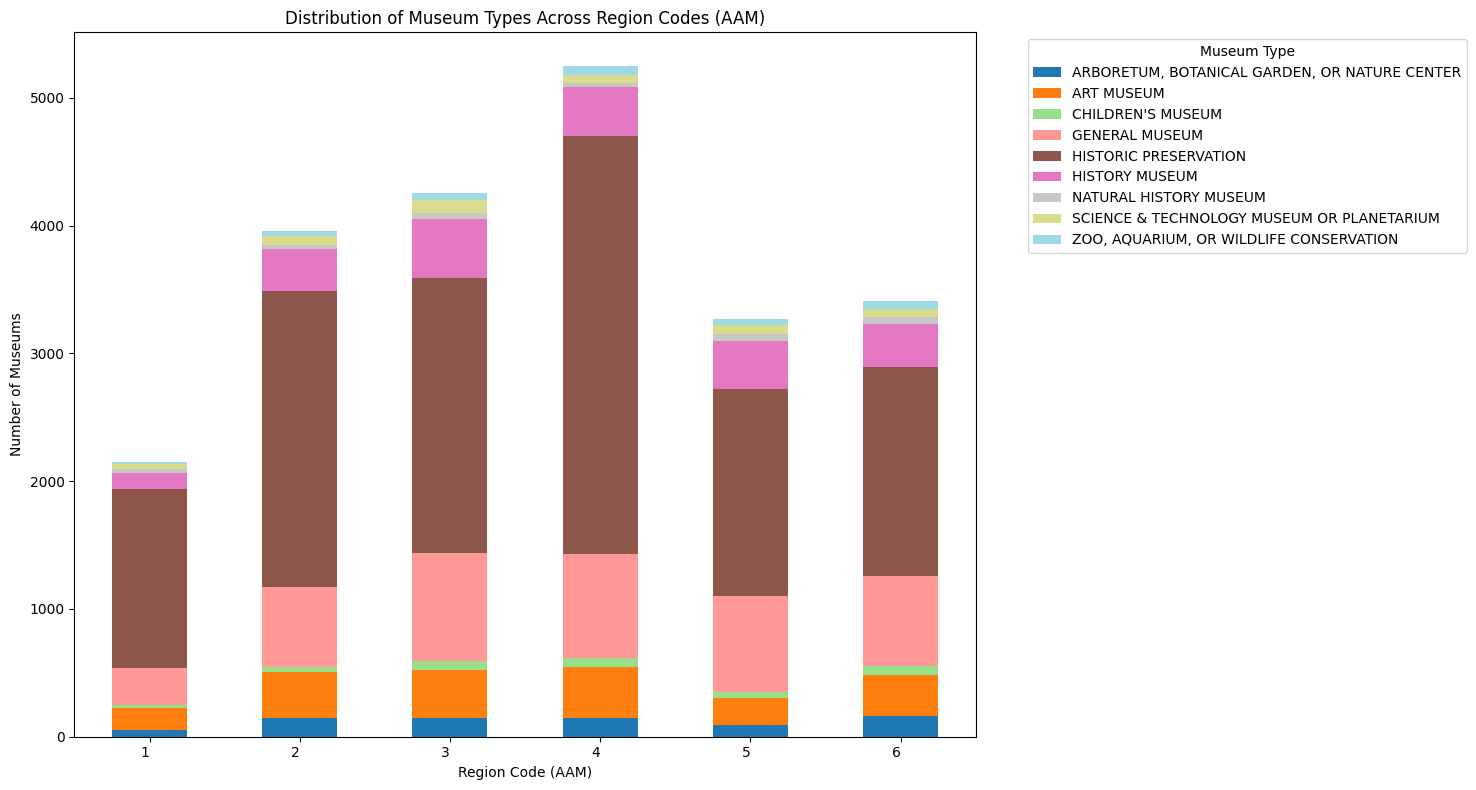

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by 'Region Code (AAM)' and 'Museum Type' and count occurrences
region_museum_distribution = df_cleaned.groupby(['Region Code (AAM)', 'Museum Type']).size().unstack(fill_value=0)

# Normalize the counts to show distribution within each region (optional, but good for relative comparison)
# region_museum_distribution = region_museum_distribution.div(region_museum_distribution.sum(axis=1), axis=0)

# Plotting the stacked bar chart
plt.figure(figsize=(15, 8))
region_museum_distribution.plot(kind='bar', stacked=True, ax=plt.gca(), cmap='tab20')

plt.title('Distribution of Museum Types Across Region Codes (AAM)')
plt.xlabel('Region Code (AAM)')
plt.ylabel('Number of Museums')
plt.xticks(rotation=0, ha='right')
plt.legend(title='Museum Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [94]:
df['State (Administrative Location)'].value_counts()

,count
State (Administrative Location),
CA,2670
NY,2239
TX,1886
PA,1653
OH,1363
IL,1310
FL,1149
MI,1039
MA,1028


In [95]:
df['City (Administrative Location)'].value_counts()

,count
City (Administrative Location),
NEW YORK,297
WASHINGTON,228
CHICAGO,194
PHILADELPHIA,182
LOS ANGELES,162
...,...
BLACK MOUNTAIN,1
SURF CITY,1
TROUTMAN,1


In [96]:
df['Zip Code (Administrative Location)'].value_counts()

,count
Zip Code (Administrative Location),
74743,67
92101,38
19106,37
10011,27
2138,26
...,...
82225,1
83013,1
99587,1


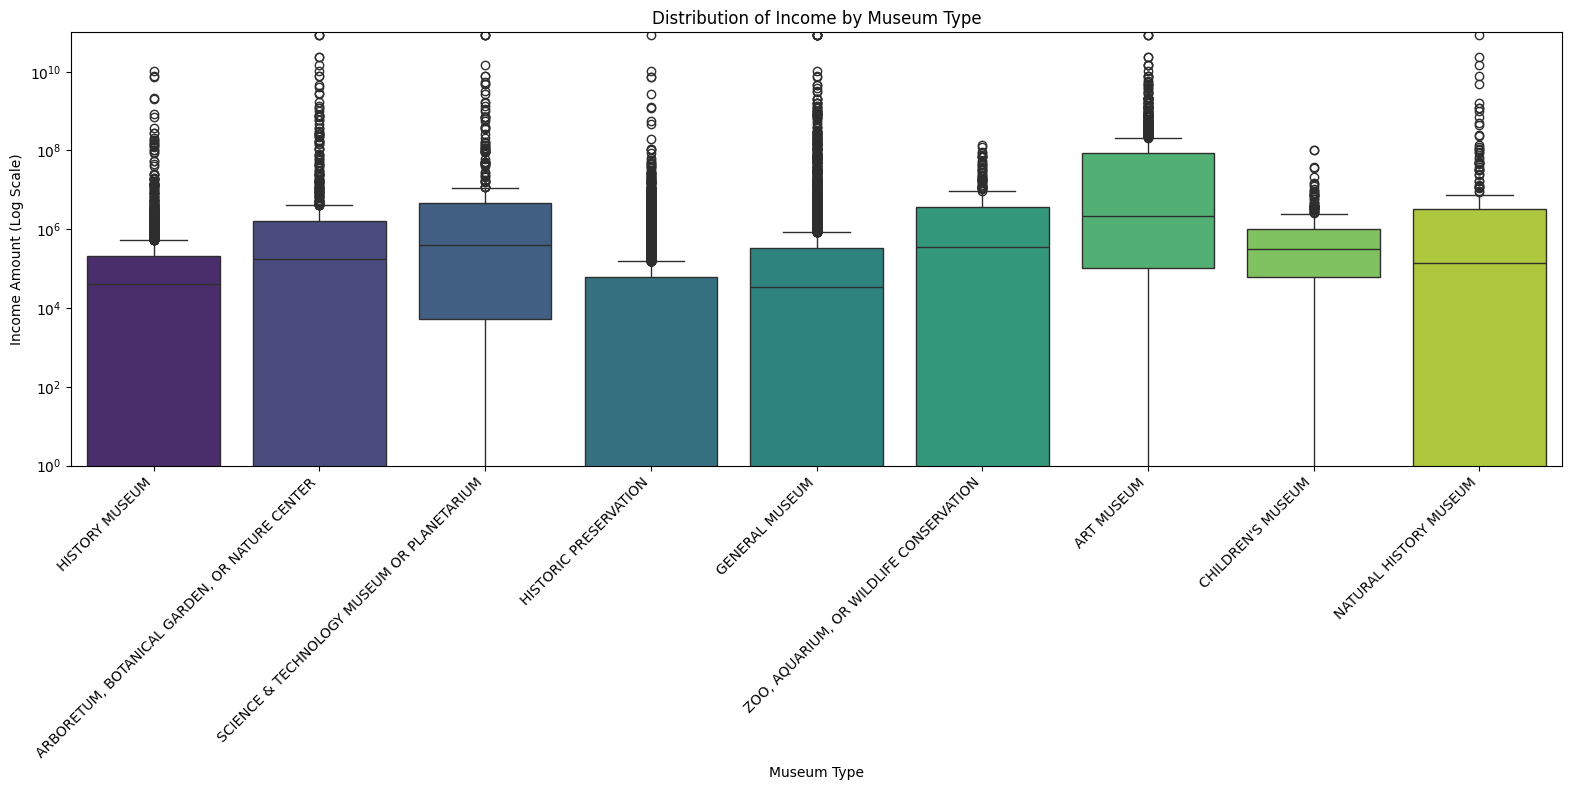

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# df_cleaned already excludes museums with unknown income or revenue.
# Melt the DataFrame to have 'Income' and 'Revenue' as a single column for plotting
melted_df = df_cleaned.melt(id_vars=['Museum Type'], value_vars=['Income', 'Revenue'],
                          var_name='Financial Metric', value_name='Amount')

# Filter to visualize only 'Income'
income_only_df = melted_df[melted_df['Financial Metric'] == 'Income']

plt.figure(figsize=(16, 8))

# Create a vertical box plot for Income only
sns.boxplot(data=income_only_df, x='Museum Type', y='Amount', hue='Museum Type', palette='viridis', legend=False)

plt.title('Distribution of Income by Museum Type')
plt.xlabel('Museum Type')
plt.ylabel('Income Amount (Log Scale)') # Update label for Income only
plt.yscale('log') # Apply log scale to the y-axis for better visualization of skewed data
plt.ylim(1, 1e11) # Set y-axis limits from 10 to 10^11
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

In [98]:
import folium
import numpy as np

# Create a copy to avoid SettingWithCopyWarning
df_map_data = df_cleaned.copy()

# Calculate Revenue-to-Income Ratio, handling division by zero
# Replace 0 income with NaN temporarily to allow for proper inf handling later
df_map_data['Income_for_ratio'] = df_map_data['Income'].replace(0, np.nan)
df_map_data['Revenue_to_Income_Ratio'] = df_map_data['Revenue'] / df_map_data['Income_for_ratio']

# Handle cases where Income was 0 and Revenue was > 0 (resulting in np.inf)
# These should rank highest, so we can assign a very large number.
# Or, if both Income and Revenue were 0, the ratio would be NaN, which we can fill with 0.
# First, fill np.nan (from Income=0, Revenue=0 or original NaNs) with 0
df_map_data['Revenue_to_Income_Ratio'] = df_map_data['Revenue_to_Income_Ratio'].fillna(0)

# Now, for cases where Income was 0 and Revenue > 0 (which became inf), replace with a very large number
# This ensures they rank at the top.
if np.isinf(df_map_data['Revenue_to_Income_Ratio']).any():
    max_finite_ratio = df_map_data['Revenue_to_Income_Ratio'][np.isfinite(df_map_data['Revenue_to_Income_Ratio'])].max()
    # Set inf values to something larger than any finite ratio
    df_map_data['Revenue_to_Income_Ratio'] = df_map_data['Revenue_to_Income_Ratio'].replace(np.inf, max_finite_ratio * 2 + 1e9) # Add a constant to ensure it's larger

# Drop rows with missing Latitude or Longitude for mapping
df_map_data.dropna(subset=['Latitude', 'Longitude'], inplace=True)

# Sort by Revenue-to-Income Ratio in descending order and get the top 50
top_50_museums = df_map_data.sort_values(by='Revenue_to_Income_Ratio', ascending=False).head(50)

# Get the mean latitude and longitude to center the map for the top 50 museums
mean_latitude_top50 = top_50_museums['Latitude'].mean()
mean_longitude_top50 = top_50_museums['Longitude'].mean()

# Create a Folium map centered around the average coordinates of the top 50 museums
m = folium.Map(location=[mean_latitude_top50, mean_longitude_top50], zoom_start=4)

# Add markers for each of the top 50 museums
for index, row in top_50_museums.iterrows():
    # Create a tooltip with Museum Name and Revenue-to-Income Ratio
    tooltip_text = f"Museum: {row['Museum Name']}<br>Ratio: {row['Revenue_to_Income_Ratio']:.2f}"

    # Determine marker color based on Revenue-to-Income Ratio
    if np.isclose(row['Revenue_to_Income_Ratio'], 1.0):
        marker_color = 'red'
    else:
        marker_color = 'blue' # Default color for other markers

    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        tooltip=tooltip_text,
        icon=folium.Icon(color=marker_color)
    ).add_to(m)

# Display the map
m

In [99]:
import folium
import numpy as np

# Create a copy to avoid SettingWithCopyWarning
df_map_data_lowest = df_cleaned.copy()

# Calculate Revenue-to-Income Ratio, handling division by zero
# Replace 0 income with NaN temporarily to allow for proper inf handling later
df_map_data_lowest['Income_for_ratio'] = df_map_data_lowest['Income'].replace(0, np.nan)
df_map_data_lowest['Revenue_to_Income_Ratio'] = df_map_data_lowest['Revenue'] / df_map_data_lowest['Income_for_ratio']

# Handle cases where Income was 0 and Revenue was > 0 (resulting in np.inf)
# For lowest ratios, we want to treat NaNs and infinites carefully.
# If Income is 0 and Revenue is 0, ratio is NaN. If Income is 0 and Revenue > 0, ratio is inf. If Revenue is 0 and Income > 0, ratio is 0.
# We will fill NaNs (from 0/0) with 0 and ensure infs (from X/0 where X>0) are high values, so they don't get picked as 'lowest'.

df_map_data_lowest['Revenue_to_Income_Ratio'] = df_map_data_lowest['Revenue_to_Income_Ratio'].fillna(0) # 0/0 -> 0

# For cases where Income was 0 and Revenue > 0, the ratio will be inf. We want to exclude these from 'lowest' or give them a very high rank.
# Replace actual inf values (from Revenue > 0 / Income = 0) with a large number so they don't appear in the lowest 50.
if np.isinf(df_map_data_lowest['Revenue_to_Income_Ratio']).any():
    max_finite_ratio = df_map_data_lowest['Revenue_to_Income_Ratio'][np.isfinite(df_map_data_lowest['Revenue_to_Income_Ratio'])].max()
    df_map_data_lowest['Revenue_to_Income_Ratio'] = df_map_data_lowest['Revenue_to_Income_Ratio'].replace(np.inf, max_finite_ratio * 2 + 1e9)

# Drop rows with missing Latitude or Longitude for mapping
df_map_data_lowest.dropna(subset=['Latitude', 'Longitude'], inplace=True)

# Sort by Revenue-to-Income Ratio in ascending order and get the top 50 (lowest)
top_50_lowest_ratio_museums = df_map_data_lowest.sort_values(by='Revenue_to_Income_Ratio', ascending=True).head(50)

# Get the mean latitude and longitude to center the map for these 50 museums
mean_latitude_lowest50 = top_50_lowest_ratio_museums['Latitude'].mean()
mean_longitude_lowest50 = top_50_lowest_ratio_museums['Longitude'].mean()

# Create a Folium map centered around the average coordinates of the lowest 50 museums
m_lowest = folium.Map(location=[mean_latitude_lowest50, mean_longitude_lowest50], zoom_start=4)

# Add markers for each of the top 50 museums with the lowest ratio
for index, row in top_50_lowest_ratio_museums.iterrows():
    # Create a tooltip with Museum Name and Revenue-to-Income Ratio
    tooltip_text = f"Museum: {row['Museum Name']}<br>Ratio: {row['Revenue_to_Income_Ratio']:.2f}"
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        tooltip=tooltip_text,
        icon=folium.Icon(color='green') # Using a different color (green) for lowest ratio markers
    ).add_to(m_lowest)

# Display the map
m_lowest

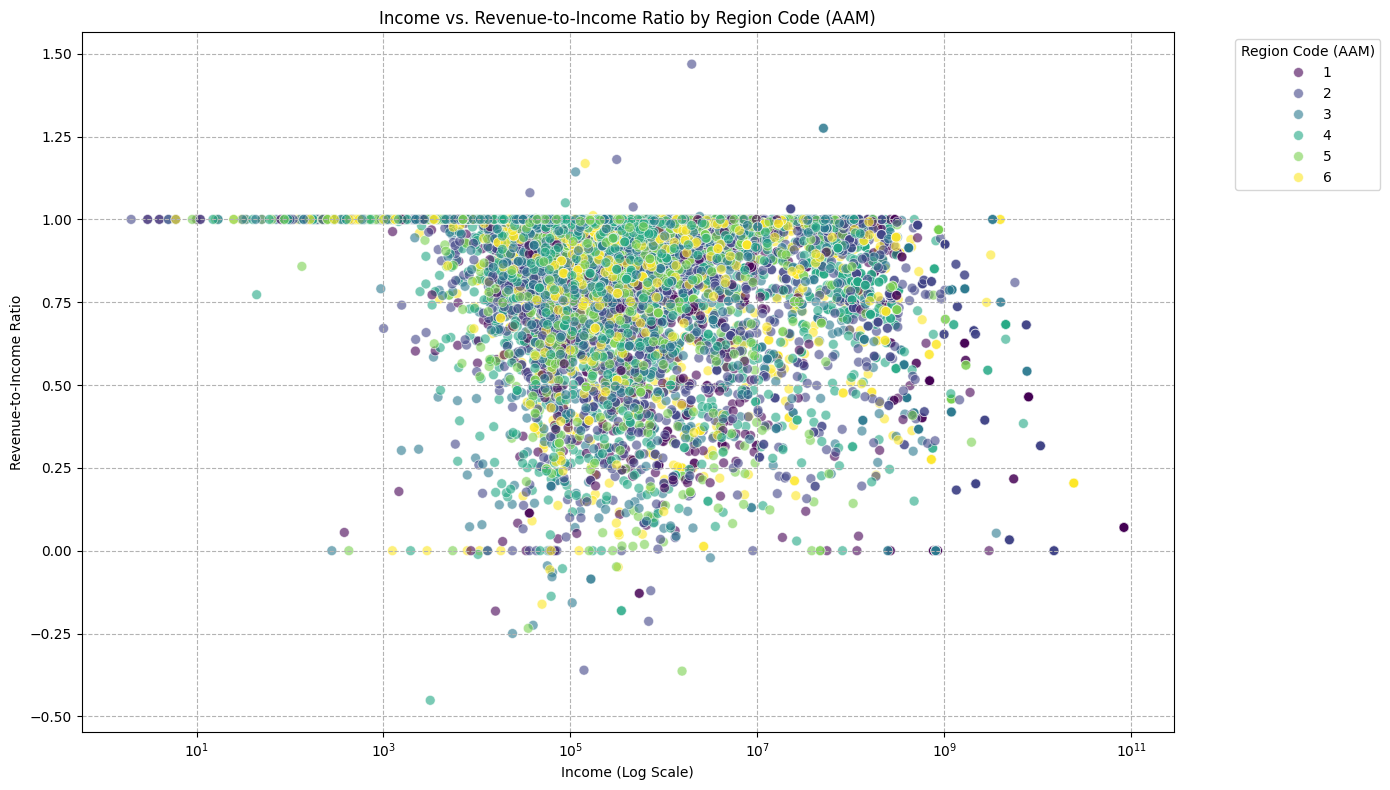

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create a copy of the cleaned DataFrame to avoid modifying the original
df_plot = df_cleaned.copy()

# Calculate Revenue-to-Income Ratio
# Replace 0 income with NaN to avoid division by zero errors leading to inf
df_plot['Income_for_ratio'] = df_plot['Income'].replace(0, np.nan)
df_plot['Revenue_to_Income_Ratio'] = df_plot['Revenue'] / df_plot['Income_for_ratio']

# Handle cases where Income was 0 and Revenue was also 0 (resulting in NaN)
# Or where Income was negative and Revenue could be anything, leading to negative ratios.
# For scatter plot, it's generally better to drop NaNs and Infs rather than capping them at arbitrary values for correlation analysis.

df_plot.dropna(subset=['Income', 'Revenue_to_Income_Ratio', 'Region Code (AAM)'], inplace=True)

# Filter out entries where Income is zero, as log scale cannot handle it
df_plot = df_plot[df_plot['Income'] > 0]

# Eliminate outliers: revenue-to-income ratio less than -0.5 and more than 1.5
df_plot = df_plot[
    (df_plot['Revenue_to_Income_Ratio'] >= -0.5) &
    (df_plot['Revenue_to_Income_Ratio'] <= 1.5)
]

# Filter out any remaining -inf or inf values from ratio calculations (should be handled by the above, but as a safeguard)
df_plot = df_plot[np.isfinite(df_plot['Revenue_to_Income_Ratio'])]

plt.figure(figsize=(14, 8))

sns.scatterplot(
    data=df_plot,
    x='Income',
    y='Revenue_to_Income_Ratio',
    hue='Region Code (AAM)', # Color by Region Code
    palette='viridis',      # Choose a color palette
    alpha=0.6,              # Set transparency for better visibility of overlapping points
    s=50                    # Adjust marker size
)

plt.xscale('log') # Apply log scale to the Income axis
# plt.yscale('log') # Consider applying log scale to ratio as well if its range is very wide

plt.title('Income vs. Revenue-to-Income Ratio by Region Code (AAM)')
plt.xlabel('Income (Log Scale)')
plt.ylabel('Revenue-to-Income Ratio')
plt.legend(title='Region Code (AAM)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="--", c='0.7')
plt.tight_layout()
plt.show()